### Report Maciej Janicki, Wojciech Bogacz

### Dependencies


In [71]:
import numpy as np
import glob
import sklearn
import matplotlib.pyplot as plt
import cvxopt
cvxopt.solvers.options['show_progress'] = False
import ipywidgets as widgets
from ipywidgets import interact


### Load Data

Results in `stocks` dictionary

In [72]:
def load_stock_data(filename):
    with open(filename, "r") as file:
        name : str
        n : int
        datapoints = []
        for i, line in enumerate(file):
            line = line.strip()
            if i == 0:
                name = line
            elif i == 1:
                n = int(line)
            else:
                _, point = line.split(" ")
                point = float(point)
                datapoints.append(point)
        assert(len(datapoints) == n)
        return name, np.array(datapoints)

In [73]:
stocks = {}
for stock_filename in glob.glob("bundle1/*.txt"):
    name, datapoints = load_stock_data(stock_filename)
    stocks[name] = datapoints
print(f"Loaded {len(stocks)} stocks")

Loaded 20 stocks


### Prediction functions and curves
esults in `stocks_predicted_ratios` dictionary.

In [74]:
# def linear_regression_prediction(datapoints, n_past_samples):
#     x = np.arange(n_past_samples,len(datapoints)).reshape(-1, 1)
#     print(x)
#     reg = sklearn.linear_model.LinearRegression().fit(x, datapoints[n_past_samples:])
#     err = np.std(datapoints[n_past_samples:] - reg.predict(x))
#     px = np.arange(len(datapoints), len(datapoints) + 100).reshape(-1, 1) # go to next T
#     return np.clip(reg.predict(px), a_min=err, a_max=np.inf), err

def create_harmonic_elements(x, harmonic_order, period_len):
    intercept = np.ones_like(x)
    components = [intercept, x]
    for order in range(1, harmonic_order+1):
        zx = 2 * np.pi * order * x / period_len
        comp = np.sin(zx) + np.cos(zx)
        components.append(comp)
    components = np.column_stack(components)
    return components
    

def harmonic_regression_prediction(datapoints, harmonic_order, period_len):
    x = create_harmonic_elements(np.arange(len(datapoints)), harmonic_order, period_len)
    reg = sklearn.linear_model.BayesianRidge().fit(x, np.log(datapoints))
    err = np.std(datapoints - np.exp(reg.predict(x)))

    px = create_harmonic_elements(np.arange(len(datapoints), len(datapoints) + 100), harmonic_order, period_len) # go to next T
    return np.exp(reg.predict(px)), err




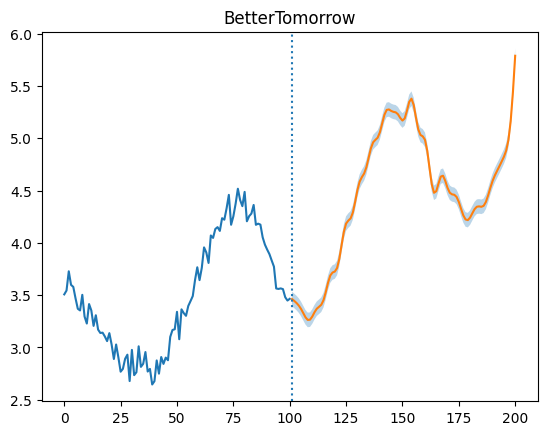

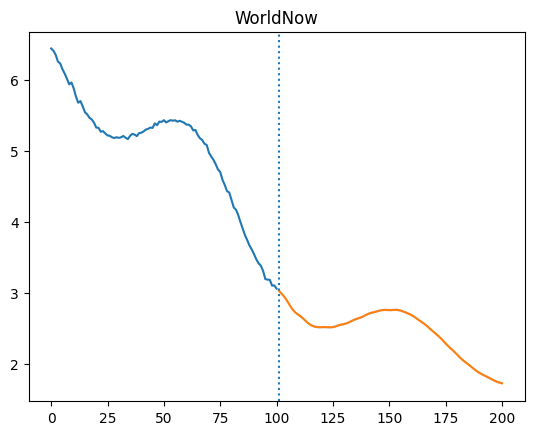

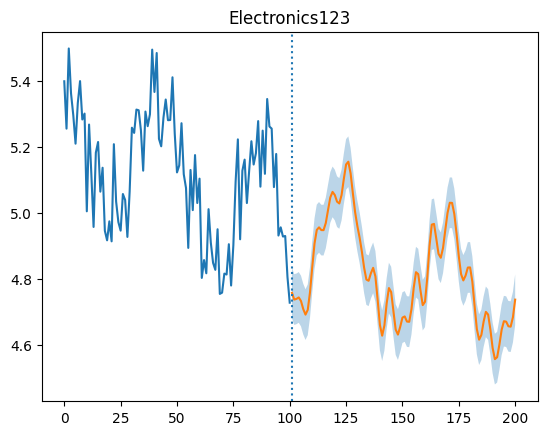

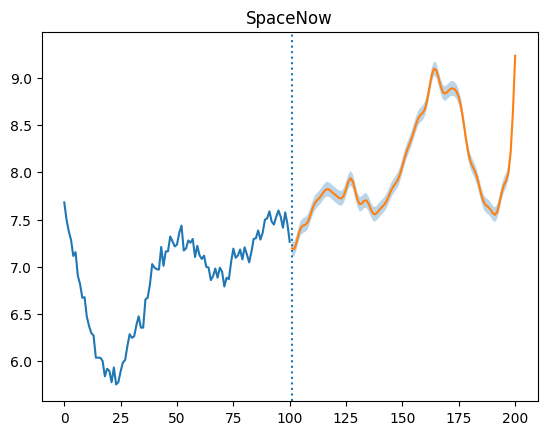

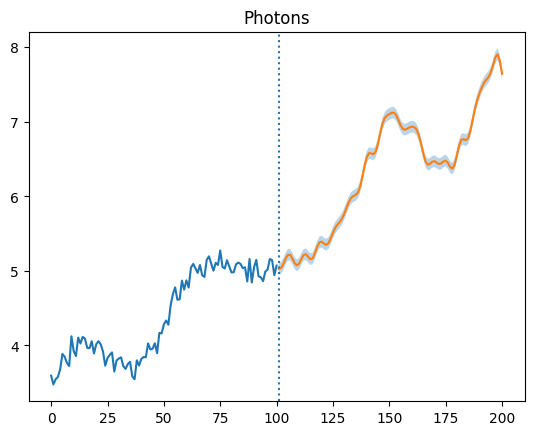

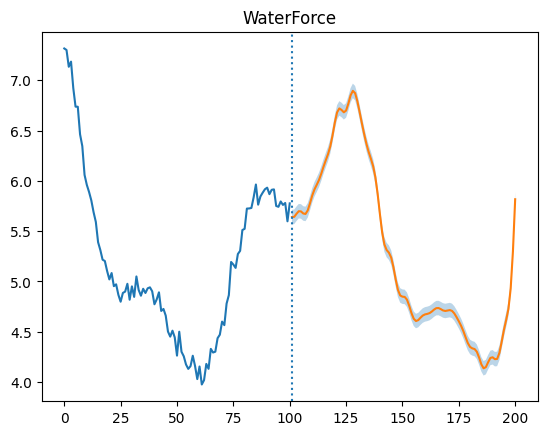

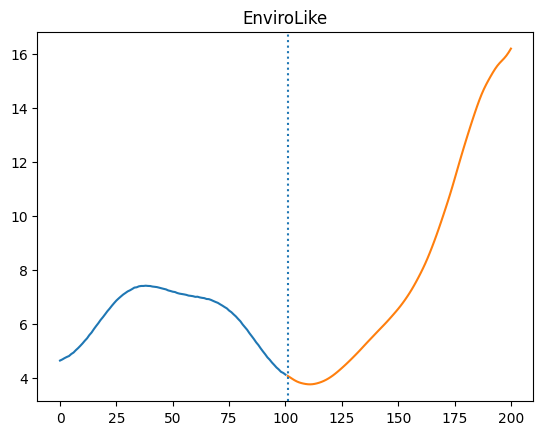

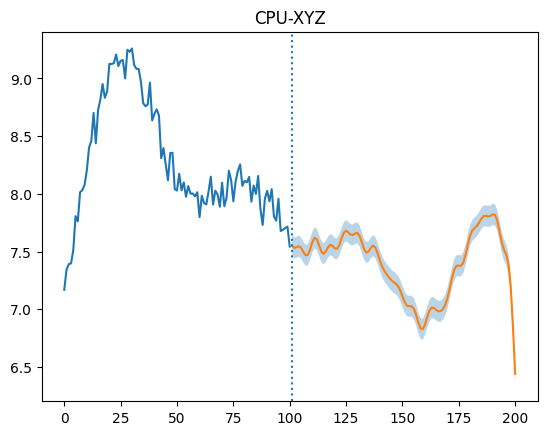

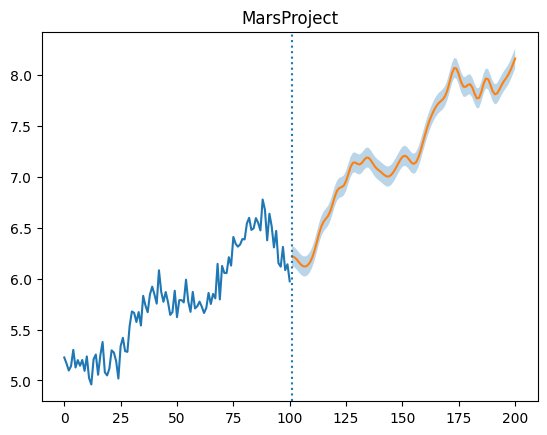

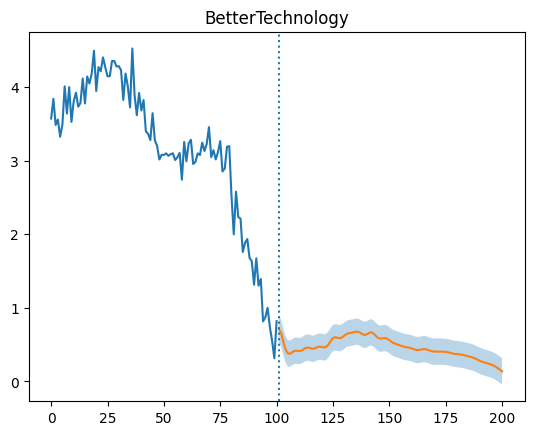

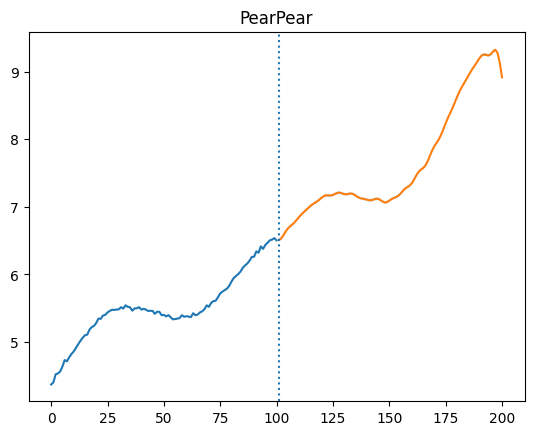

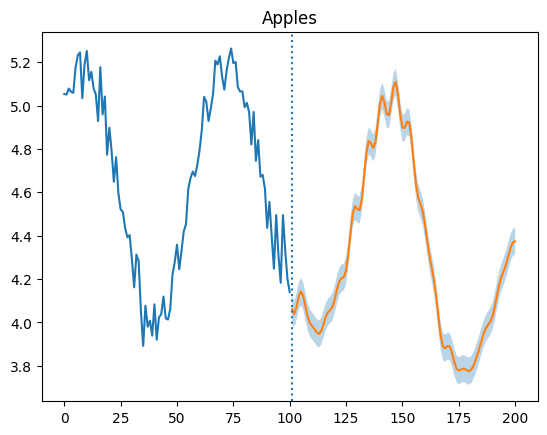

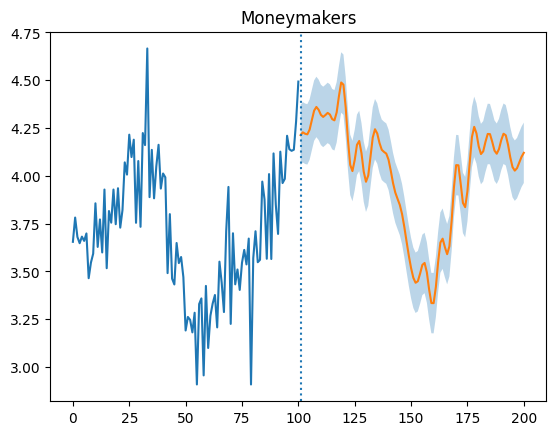

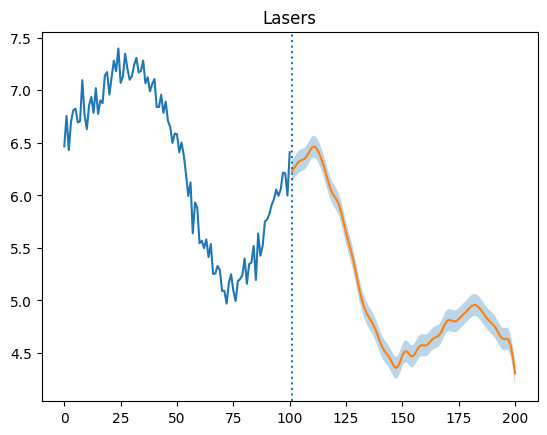

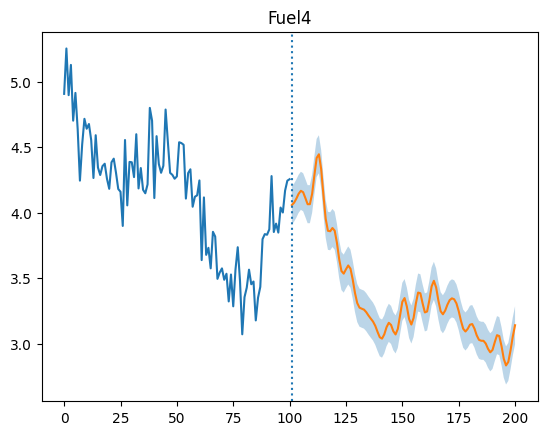

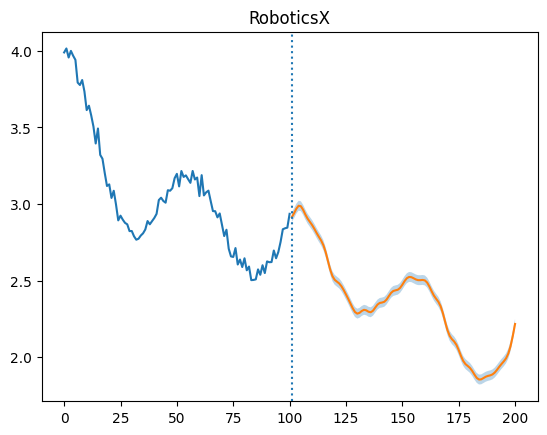

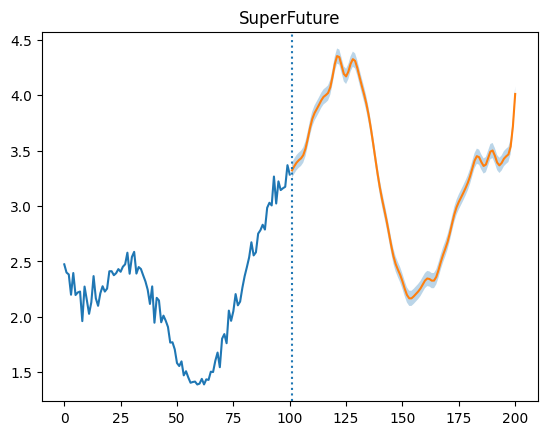

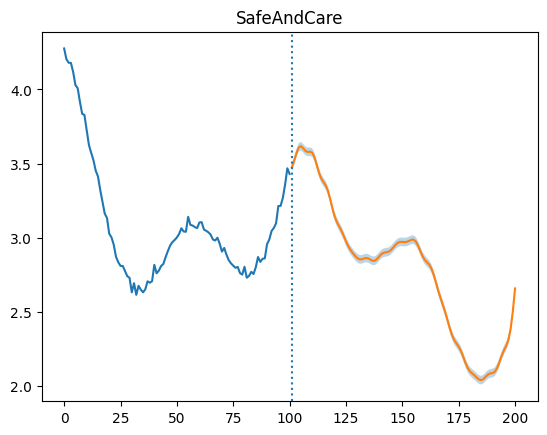

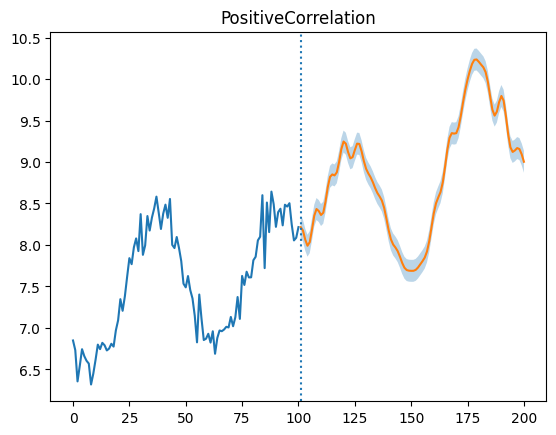

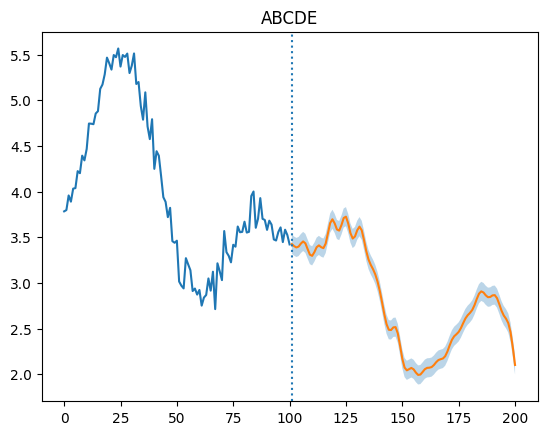

In [75]:
stocks_predicted_ratios = {} # predictions for last day only
harmonic_order=35
period_len=201
stock_predicted_values = {}
for stock_name, stock_datapoints in stocks.items():
    predictions, err = harmonic_regression_prediction(stock_datapoints,harmonic_order, period_len)
    
    stocks_predicted_ratios[stock_name] = predictions[-1] / stock_datapoints[-1]
    x = np.arange(len(stock_datapoints))
    plt.plot(x, stock_datapoints)
    px = np.arange(len(stock_datapoints), len(stock_datapoints) + 100)
    plt.plot(px, predictions)
    stock_predicted_values[stock_name] = predictions
    plt.axvline(len(stock_datapoints), linestyle="dotted")
    plt.fill_between(px, predictions - err, predictions + err, alpha=0.3)
    plt.title(stock_name)
    plt.show()


In [76]:
print(stocks_predicted_ratios)

{'BetterTomorrow': np.float64(1.6703633564854843), 'WorldNow': np.float64(0.564535263124032), 'Electronics123': np.float64(1.0019520109057287), 'SpaceNow': np.float64(1.271115851964351), 'Photons': np.float64(1.5071908150418776), 'WaterForce': np.float64(1.007117375827805), 'EnviroLike': np.float64(3.9251395313565594), 'CPU-XYZ': np.float64(0.853762720946338), 'MarsProject': np.float64(1.3664732289808967), 'BetterTechnology': np.float64(0.1673966281666613), 'PearPear': np.float64(1.3711437327051674), 'Apples': np.float64(1.056607173466597), 'Moneymakers': np.float64(0.9171113775912372), 'Lasers': np.float64(0.6716113239120197), 'Fuel4': np.float64(0.7380583260253248), 'RoboticsX': np.float64(0.7552222232805703), 'SuperFuture': np.float64(1.2213139383200515), 'SafeAndCare': np.float64(0.7744835752975817), 'PositiveCorrelation': np.float64(1.0958813104398002), 'ABCDE': np.float64(0.6142371555145255)}


### Covariance

Results in `stocks_covariance` matrix and `stocks_expected_return` vector

In [77]:
m = []
stocks_expected_return = []
for stock in stocks:
    m.append(stocks[stock])
    stocks_expected_return.append(stocks_predicted_ratios[stock])
m = np.array(m)
stocks_covariance = np.cov(m)
stocks_expected_return = np.array(stocks_expected_return) - 1

### Solve QP with Weighted Sum Method

In [78]:
def evaluate_solution(weights, expected_return, covariance_matrix):
    return np.sum(weights * (expected_return)), weights.T @ covariance_matrix @ weights

def wsm_solve(risk_weight, expected_return, covariance_matrix, normalize = True):
    n_factor_risk = 1.0
    n_factor_return = 1.0
    if normalize:
        wreturn = wsm_solve(0.0, expected_return, covariance_matrix, normalize=False)
        wrisk = wsm_solve(1.0, expected_return, covariance_matrix, normalize=False)
        max_return, max_risk = evaluate_solution(wreturn, expected_return, covariance_matrix)
        min_return, min_risk = evaluate_solution(wrisk, expected_return, covariance_matrix)
        n_factor_return = 1 / (max_return - min_return)
        n_factor_risk = 1 / (max_risk - min_risk)
    n = len(expected_return)
    Q = cvxopt.matrix(2 * risk_weight * n_factor_risk * covariance_matrix) # we have to flip for correct column layout I think
    c = cvxopt.matrix((1 - risk_weight) * expected_return * -1 * n_factor_return)
    b = cvxopt.matrix(1.0)
    A = cvxopt.matrix(np.ones(shape=(1,n)))

    G = cvxopt.matrix(-np.eye(n))
    h = cvxopt.matrix(np.zeros(n))

    sol = cvxopt.solvers.qp(Q, c, G, h, A, b)
    weights = np.array(sol['x']).flatten()
    return weights



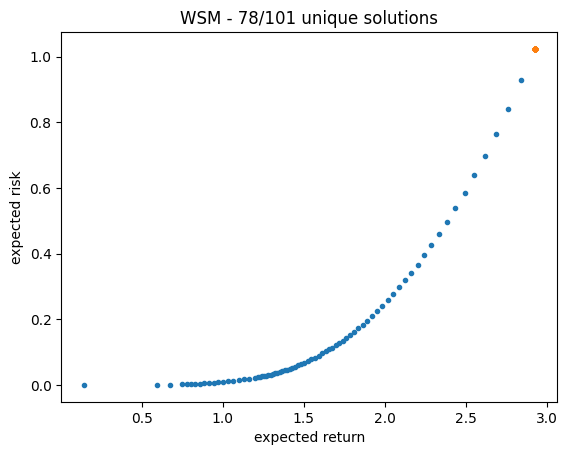

(np.float64(2.9251392673779835), np.float64(1.0231343775552146))

In [87]:
n_samples = 100
wsm_x_returns = []
wsm_y_risks = []
wsm_solutions = []
for i in range(n_samples + 1):
    wcm_weight = 1 / n_samples * i
    w = wsm_solve(wcm_weight, stocks_expected_return, stocks_covariance)
    ereturn, risk = evaluate_solution(w, stocks_expected_return, stocks_covariance)
    wsm_x_returns.append(ereturn)
    wsm_y_risks.append(risk)
    wsm_solutions.append(w)
wsm_x_returns = np.array(wsm_x_returns)


duplicates_x = []
duplicates_y = []
unique_x = []
unique_y = []


for i in range(len(wsm_solutions)):
    duplicate = False
    for j in range(i + 1, len(wsm_solutions)):
        if np.linalg.norm(wsm_solutions[i] - wsm_solutions[j]) <= 1e-5:
            duplicate = True
            duplicates_x.append(wsm_x_returns[i])
            duplicates_y.append(wsm_y_risks[i])
            break
    if not duplicate:
        unique_x.append(wsm_x_returns[i])
        unique_y.append(wsm_y_risks[i])


plt.scatter(unique_x, unique_y, marker=".")
plt.scatter(duplicates_x, duplicates_y, marker=".")
plt.xlabel("expected return")
plt.ylabel("expected risk")
plt.title(f"WSM - {len(unique_x)}/{len(wsm_solutions)} unique solutions")
plt.show()


evaluate_solution(wsm_solutions[0], stocks_expected_return, stocks_covariance)

### epsilon constrained method

In [80]:
def ecm_solve(epsilon, expected_return, covariance_matrix):
    n = len(expected_return)
    Q = cvxopt.matrix(2 * covariance_matrix) # we have to flip for correct column layout I think
    c = cvxopt.matrix(np.zeros(n))
    b = cvxopt.matrix(1.0)
    A = cvxopt.matrix(np.ones(shape=(1,n)))

    G = cvxopt.matrix(np.vstack((-expected_return,-np.eye(n))))
    h = np.zeros(n+1)
    h[0] = -epsilon
    h = cvxopt.matrix(h)

    sol = cvxopt.solvers.qp(Q, c, G, h, A, b)
    weights = np.array(sol['x']).flatten()
    return weights





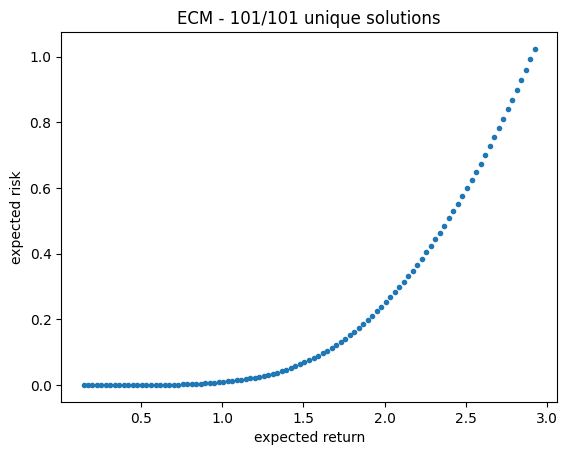

In [89]:
threshold_step = (np.max(wsm_x_returns)-np.min(wsm_x_returns))/n_samples
ecm_x_returns = []
ecm_y_risks = []
ecm_solutions = []
for i in range(n_samples + 1):
    t = i * threshold_step + np.min(wsm_x_returns)
    w = ecm_solve(t, stocks_expected_return, stocks_covariance)
    ereturn, risk = evaluate_solution(w, stocks_expected_return, stocks_covariance)
    ecm_x_returns.append(ereturn)
    ecm_y_risks.append(risk)
    ecm_solutions.append(w)

duplicates_x = []
duplicates_y = []
unique_x = []
unique_y = []


for i in range(len(ecm_solutions)):
    duplicate = False
    for j in range(i + 1, len(ecm_solutions)):
        if np.linalg.norm(ecm_solutions[i] - ecm_solutions[j]) <= 1e-5:
            duplicate = True
            duplicates_x.append(ecm_x_returns[i])
            duplicates_y.append(ecm_y_risks[i])
            break
    if not duplicate:
        unique_x.append(ecm_x_returns[i])
        unique_y.append(ecm_y_risks[i])


plt.scatter(unique_x, unique_y, marker=".")
plt.scatter(duplicates_x, duplicates_y, marker=".")
plt.xlabel("expected return")
plt.ylabel("expected risk")
plt.title(f"ECM - {len(unique_x)}/{len(wsm_solutions)} unique solutions")
plt.show()



Expected return: 0.81, expected risk: 0.01


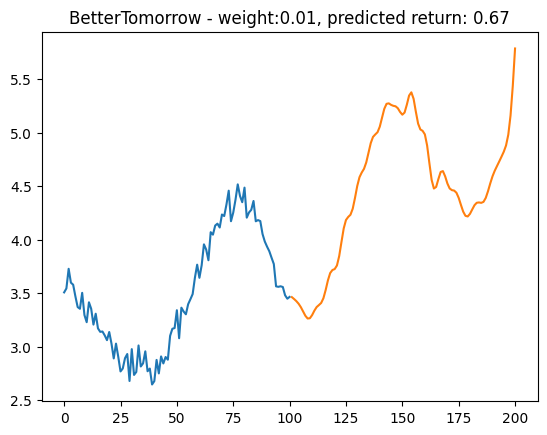

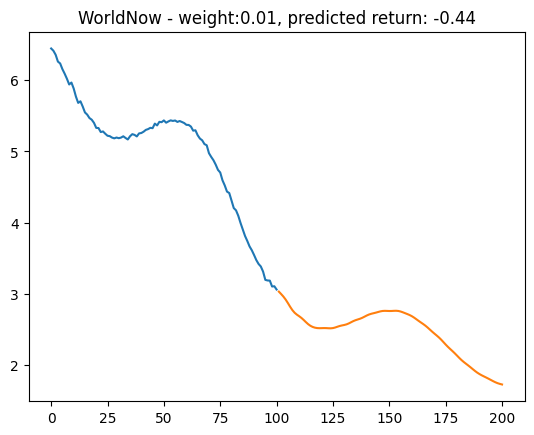

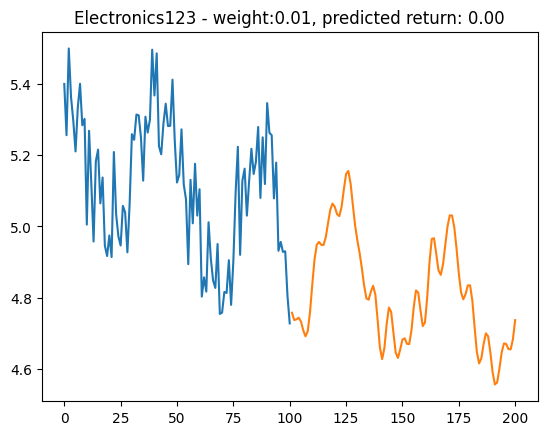

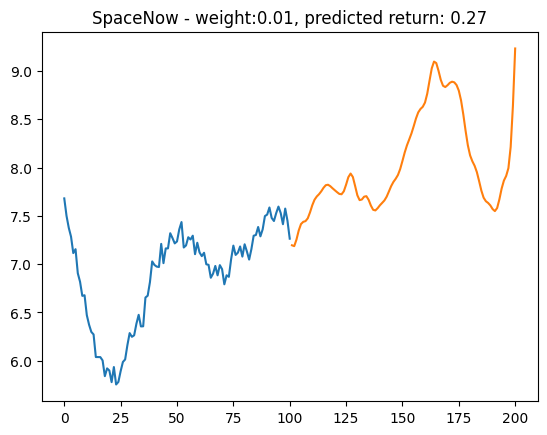

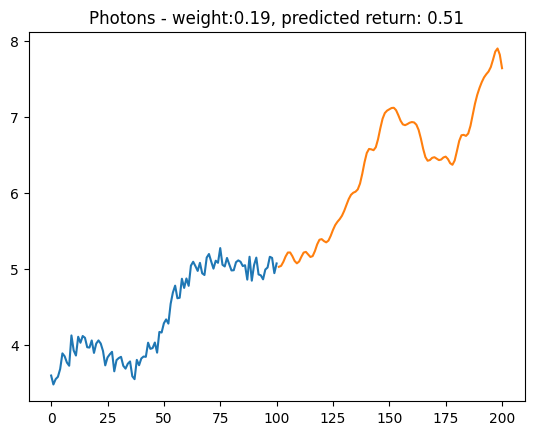

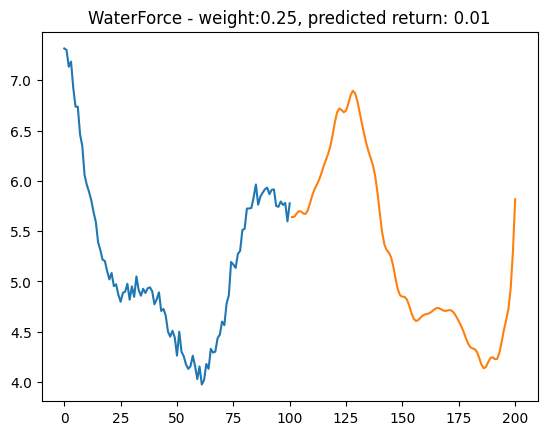

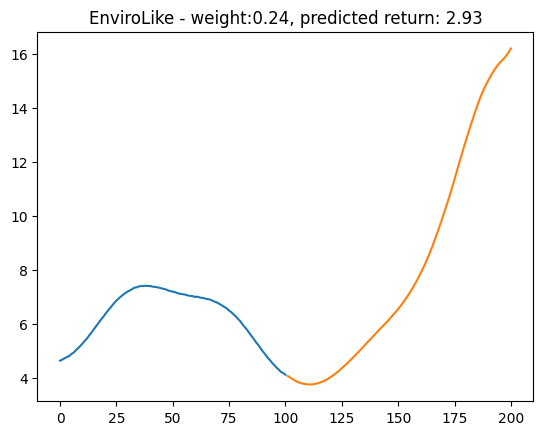

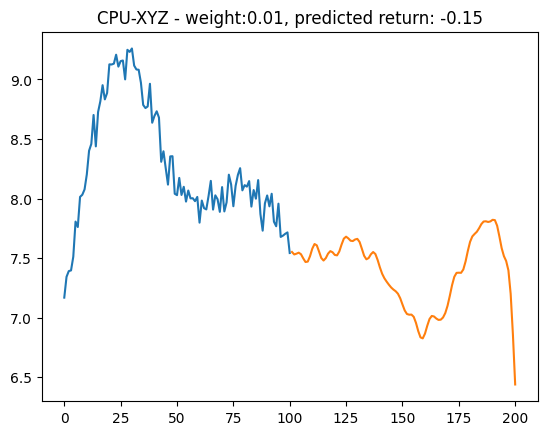

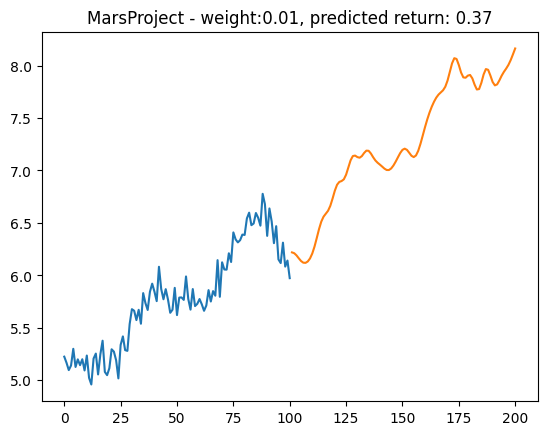

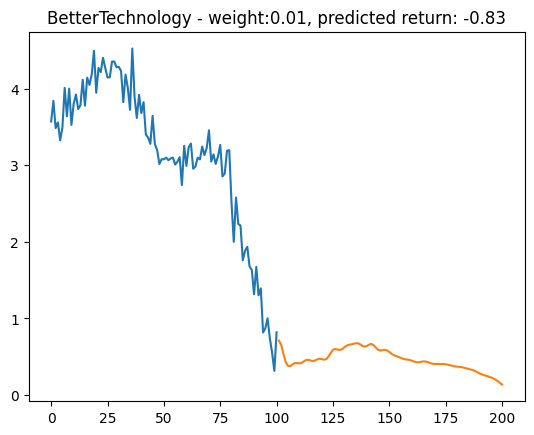

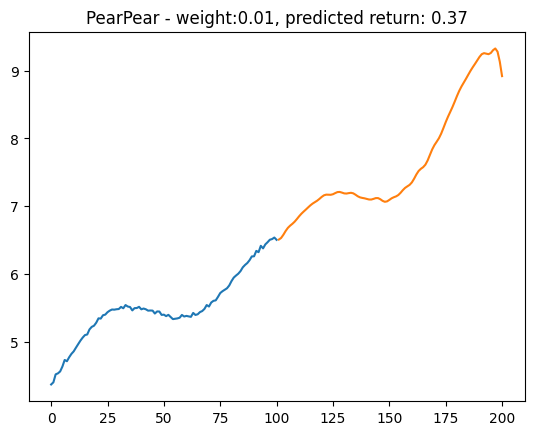

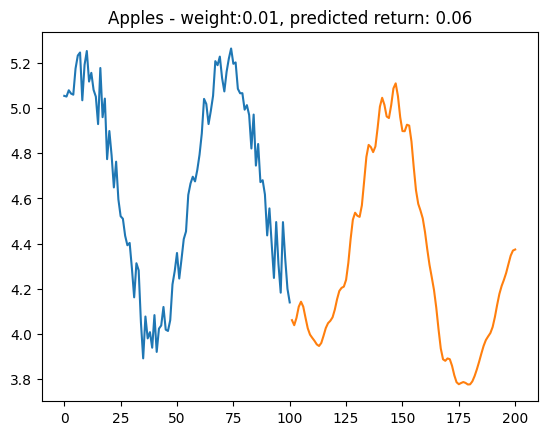

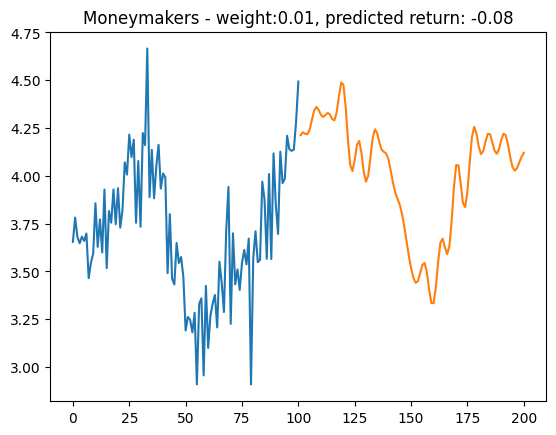

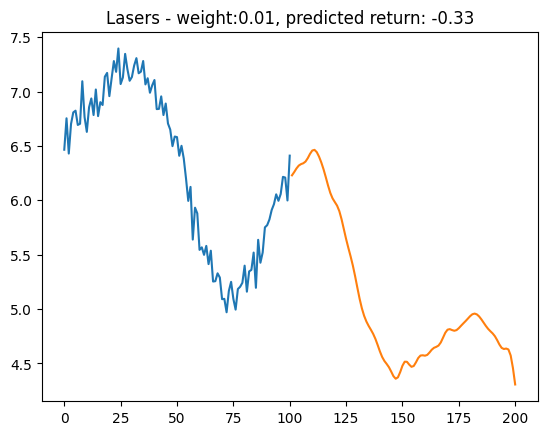

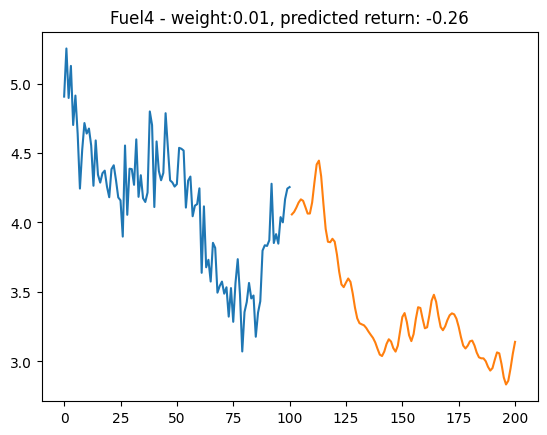

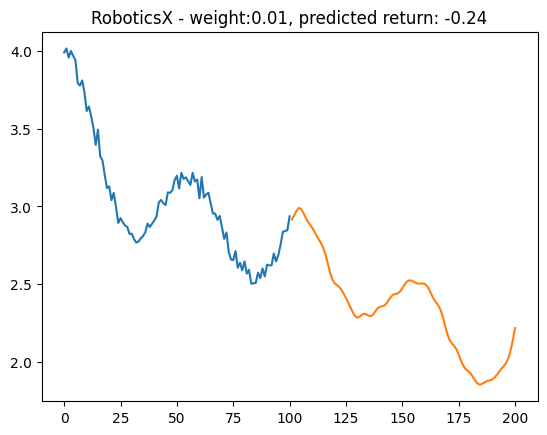

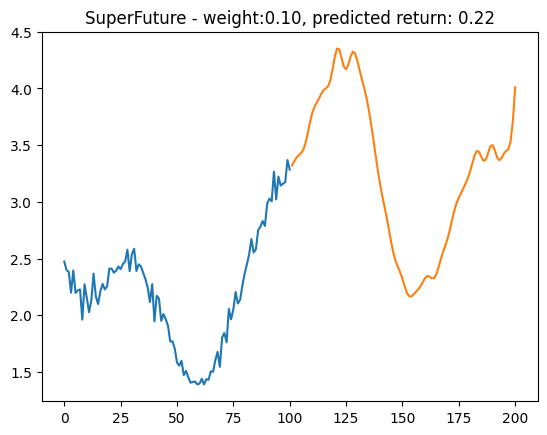

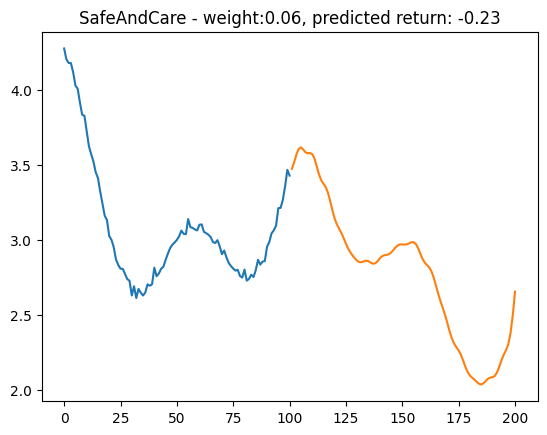

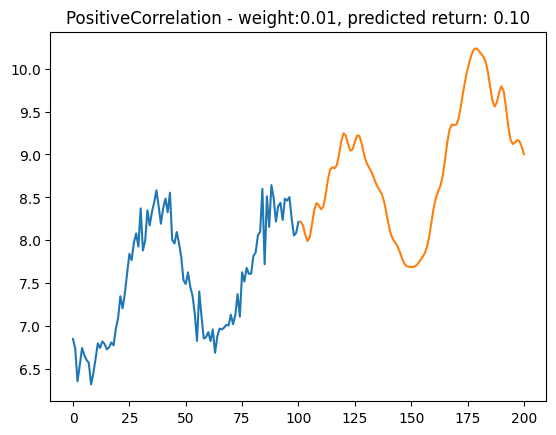

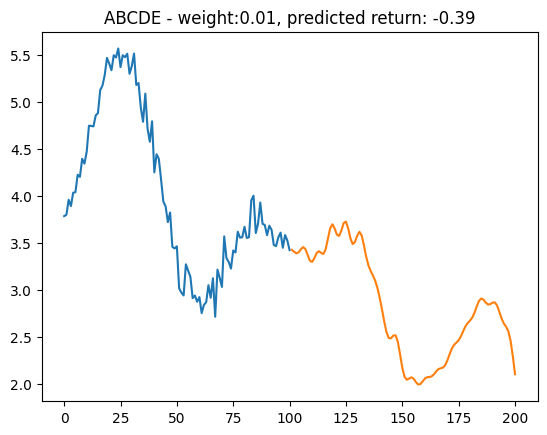

In [82]:
chosen_weights = None
max_risk = 0.015
for i, ret in enumerate(ecm_y_risks):
    if ret >= max_risk:
        chosen_weights = ecm_solutions[i]
        break

for i in range(len(chosen_weights)):
    if chosen_weights[i] <= 0.0001:
        chosen_weights[i] = 0.01
        chosen_weights[np.argmax(chosen_weights)] -= 0.01

ereturn, erisk = evaluate_solution(chosen_weights, stocks_expected_return, stocks_covariance)

print(f"Expected return: {ereturn:.2f}, expected risk: {erisk:.2f}")

for i, key in enumerate(stocks):
    stock_datapoints = stocks[key]
    x = np.arange(len(stock_datapoints))
    plt.title(f"{key} - weight:{chosen_weights[i]:.2f}, predicted return: {stocks_predicted_ratios[key] - 1:.2f}")
    plt.plot(x, stock_datapoints)
    predictions = stock_predicted_values[key]
    px = np.arange(len(stock_datapoints), len(stock_datapoints) + 100)
    plt.plot(px, predictions)
    plt.show()



In [83]:
assert np.sum(chosen_weights) - 1.0 < 1e-9

stock_chosen_weights = {}
for i, stock in enumerate(stocks):
    stock_chosen_weights[stock] = chosen_weights[i]


stocks_order = ["SuperFuture",
    "Apples",
    "WorldNow",
    "Electronics123",
    "Photons",
    "SpaceNow",
    "PearPear",
    "PositiveCorrelation",
    "BetterTechnology",
    "ABCDE",
    "EnviroLike",
    "Moneymakers",
    "Fuel4",
    "MarsProject",
    "CPU-XYZ",
    "RoboticsX",
    "Lasers",
    "WaterForce",
    "SafeAndCare",
    "BetterTomorrow",]

correct_weight_order = [str(ereturn), str(erisk)]
for stock in stocks_order :
    print(stock, stock_chosen_weights[stock])
    correct_weight_order.append(str(stock_chosen_weights[stock]))
with open("156073_156034.txt", "w") as file:
    file.write(" ".join(correct_weight_order))


SuperFuture 0.09960214163294633
Apples 0.01
WorldNow 0.01
Electronics123 0.01
Photons 0.1943257938735848
SpaceNow 0.01
PearPear 0.01
PositiveCorrelation 0.01
BetterTechnology 0.01
ABCDE 0.01
EnviroLike 0.24462180670997424
Moneymakers 0.01
Fuel4 0.01
MarsProject 0.01
CPU-XYZ 0.01
RoboticsX 0.01
Lasers 0.01
WaterForce 0.24851073150834707
SafeAndCare 0.06293932416372817
BetterTomorrow 0.01
